# Short the diamond — a quantitative teardown 🔬
### Price index vs SPY (CAGR / vol / MDD + an annual-excess *t*) · Newey-West proxy alpha · a borrow-charged short book · the retail→resale haircut · a synthetic collapse positive control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Diamonds_collapsing%3F: Confirmed](https://img.shields.io/badge/Diamonds_collapsing%3F-Confirmed-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). We test the strongest tradable form of "lab-grown is killing the natural diamond, short it": (H₁) the natural-diamond price index falls vs SPY (the *diagnosis*); (H₂) a listed proxy carries a harvestable alpha — long the survivor or short the loser — vs the market; (H₃) the short survives borrow and the physical stone survives the resale spread. We find **H₁ confirmed** (the diagnosis is real), **H₂ rejected** (no significant alpha; \|*t*\| < 2), **H₃ rejected** (the short loses net of borrow; the stone loses net of spread).

> ⚠️ **Not investment advice — data provenance.** The price index is **hardcoded, cited, approximate** (public Rapaport RAPI / IDEX / Zimnisky reporting — a *labelled proxy*, never the live feed). Equity proxies `SIG`, `LUC.TO`, `SPY` are month-end Adj Close via yfinance (as-of 2025-12-31). Offline core + synthetic control are deterministic. Methods in [`docs/references.md`](../docs/references.md); numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from diamond_price_index import data, strategy as st

HAVE_PROXIES = data.have_proxies()
IDX = data.load_price_index()                        # hardcoded, cited, APPROXIMATE proxy
PROX = data.load_proxies() if HAVE_PROXIES else None
print("equity-proxy cache present:", HAVE_PROXIES,
      "| price-index years:", IDX.index[0].year, "->", IDX.index[-1].year)

# frozen headline numbers (mirror of docs/results.md)
R = {'win': '2018 → 2025', 'idx_levels': {2018: 100, 2019: 94, 2020: 96, 2021: 118, 2022: 122, 2023: 104, 2024: 92, 2025: 90}, 'idx_yoy': {2019: -6.0, 2020: 2.1, 2021: 22.9, 2022: 3.4, 2023: -14.8, 2024: -11.5, 2025: -2.2}, 'peak_date': '2022-02', 'peak_level': 132, 'peak_trough': -31.8, 'idx_cagr': -1.49, 'idx_vol': 12.4, 'idx_sharpe': -0.07, 'idx_mdd': -26.2, 'spy_cagr_ye': 17.18, 'spy_vol_ye': 16.9, 'spy_mdd_ye': -18.2, 'excess_mean': -19.27, 'excess_t': -2.302, 'excess_p': 0.061, 'excess_n': 7, 'sig_cagr': 17.05, 'sig_vol': 66.2, 'sig_sharpe': 0.61, 'sig_mdd': -77.8, 'sig_alpha': 7.32, 'sig_beta': 1.91, 'sig_t': 0.32, 'sig_p': 0.753, 'sig_n': 84, 'luc_cagr': -24.27, 'luc_vol': 49.6, 'luc_sharpe': -0.32, 'luc_mdd': -88.8, 'luc_alpha': -26.0, 'luc_beta': 0.82, 'luc_t': -1.73, 'luc_p': 0.087, 'luc_n': 84, 'luc_total': -85.7, 'spy_cagr': 17.18, 'spy_vol': 16.6, 'spy_sharpe': 1.04, 'spy_mdd': -23.9, 'short_cagr': -22.59, 'short_vol': 49.6, 'short_sharpe': -0.22, 'short_mdd': -93.5, 'short_borrow': 30, 'short_nb_cagr': 1.91, 'short_nb_total': 13.9, 'haircut_gross': -1.49, 'haircut_spread': -14.76, 'haircut_insure': -0.5, 'haircut_net': -16.45, 'syn_peak': 201, 'syn_end': 86, 'syn_back_cagr': -17.01, 'syn_sharpe': -0.08, 'syn_mdd': -58.6}


equity-proxy cache present: True | price-index years: 2018 -> 2025


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | No tradable leg clears \|*t*\| ≥ 2 in the trade's favour: SIG alpha *t*=**+0.32**, LUC.TO alpha *t*=**-1.73**. The index's −19%/yr shortfall (*t*=-2.30) is on a **hardcoded proxy** and measures the *diagnosis*, not a harvestable edge. |
| **Tradability** | `MIRAGE` | Short the miner net of 30%/yr borrow: **-22.6%/yr** (the miner fell -86% yet the short lost — vol drag + borrow). Physical stone net of resale spread: **-16.4%/yr**. No diamond future; nothing scales. |
| **Diamonds collapsing?** | `CONFIRMED` | The price index round-tripped **-32%** off its early-2022 peak; lab-grown wholesale fell ~80–90%. The *diagnosis* is real — it just isn't a trade. |

> 💡 In plain words: the bear thesis on diamonds is **correct** and yet **untradable**. Every listed expression is idiosyncratic beta, the short is eaten by borrow and volatility drag, and the physical stone is a spending decision. Being right about a collapse and getting paid for it are different problems.

## 1 · The claim, steelmanned

Let the natural-diamond price index be $I_t$ and the benchmark $B_t$ (SPY). The bear-trade claim is a joint hypothesis:

- **H₁ (the collapse is real).** Annual $r^I_t < r^B_t$ with the index falling in level — the diagnosis. *(This one we expect to hold.)*
- **H₂ (a listed leg monetises it).** For a tradable proxy $P$, the intercept $\alpha$ in $r^P_t = \alpha + \beta r^B_t + \varepsilon_t$ clears a Newey-West \|*t*\| > 2 in the trade's favour (positive for a survivor long, negative for a short).
- **H₃ (the trade survives frictions).** A short book net of borrow $b$ keeps a positive CAGR; **and** the physical stone's net CAGR after the retail→resale round-trip $s$ over hold $h$ and carry $c$ stays positive.

The steelman is that H₁ is *unusually* well-supported — this is not a manufactured bubble, it's a genuine technological displacement. The test is whether that rare, correct macro call converts into P&L through H₂ and H₃. It does not.

## 2 · So what? — what rides on each answer

If H₁–H₃ held, this would be the rarest thing in markets: a slow, obvious, correctly-diagnosed decline you could simply be short. But each leg is separately falsifiable. H₁ is a **level check** — did diamonds fall? H₂ asks whether the *only investable expressions* (listed equities) carry anything beyond market beta — you cannot short "the index" or a polished stone directly. H₃ is the **microstructure tax**: a short pays borrow (punishing on an illiquid penny-stock miner) and suffers convexity against it on up-moves, while a physical diamond carries a ~50–70% retail→resale round-trip. The trade needs all three; H₁ alone is a diagnosis, not a position.

## 3 · How we'd know — the protocol

- **Price index (proxy).** A hardcoded, cited, **approximate** annual level (base 100 @ 2018), reconstructed from public Rapaport RAPI / IDEX / Zimnisky / press figures (early-2022 peak; ~−18%/−11% for 2023/24). *Labelled a proxy* — its path is defensible, its precise year-end values are not a live feed, and its smoothness **inflates** any *t* built on it.
- **Equity proxies.** `SIG`, `LUC.TO`, `SPY` month-end Adj Close (yfinance, cached). Survivorship is **not** the concern (named tickers, not a screen) — but note the *opposite* selection risk: Lucara is **one** surviving small miner, so its idiosyncratic path can't be read as "diamond beta," a caveat that travels with the stamp.
- **Signal test.** (i) Paired annual-excess $t$ of $r^I - r^B$ (small-$n$, on the proxy index — a *diagnosis* statistic, not a tradable one). (ii) **Newey-West (6-lag) HAC** $t$ of each proxy's alpha vs SPY — the bar for `REAL` is \|*t*\| ≥ 2 in the trade's favour.
- **Cost (beat 6).** A $1 short book charged **30%/yr borrow** monthly (hard-to-borrow penny-stock); and the physical stone's retail→resale round-trip (55% over a 5y hold) + carry **once on NAV**.
- **Positive control.** A deterministic peak-and-**collapse** path with a *planted negative* post-peak drift; the engine must recover the **down**-sign — proof a null on the real tape is a real null, not a broken harness.
- **What would make us say "tradable":** a proxy alpha \|*t*\| > 2 in the trade's favour **and** a positive net-of-friction CAGR. We find neither.

## 4 · The teardown

### 4a · The diagnosis — price index vs SPY (H₁)

Year-end levels rebased to \$100, both series on one clock. CAGR, vol and max-drawdown in the print. This leg we *expect* to confirm — diamonds fell.

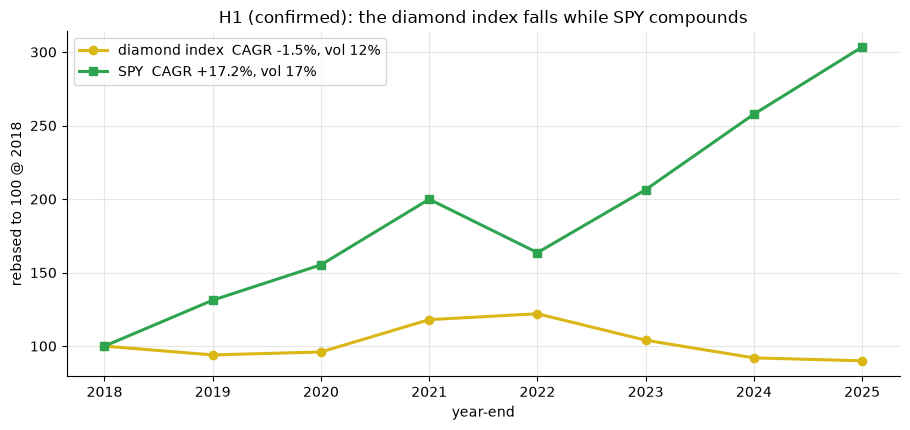

index: CAGR -1.49%  vol 12.4%  maxDD -26.2%
SPY  : CAGR +17.18%  vol 16.9%  maxDD -18.2%
annual excess (idx-SPY): mean -19.27%/yr  t=-2.302  (n=7)


In [2]:
yrs = list(R['idx_levels'].keys())
lv = np.array([float(IDX.loc[f'{y}-12-31']) for y in yrs])
if HAVE_PROXIES:
    spy_ye = PROX['SPY'].resample('YE').last()
    spy_ye = spy_ye[(spy_ye.index.year>=2018)&(spy_ye.index.year<=2025)]
    spy = (spy_ye/spy_ye.iloc[0]*100).values; sx=[d.year for d in spy_ye.index]
    si = st.summarize(IDX, periods_per_year=1.0)
    ss = st.summarize(spy_ye, periods_per_year=1.0)
    ae = st.annual_excess_t(IDX, PROX['SPY'])
else:
    spy = np.array([100*(1+R['spy_cagr_ye']/100)**(y-2018) for y in yrs]); sx=yrs
    si={'cagr':R['idx_cagr']/100,'vol':R['idx_vol']/100,'mdd':R['idx_mdd']/100}
    ss={'cagr':R['spy_cagr_ye']/100,'vol':R['spy_vol_ye']/100,'mdd':R['spy_mdd_ye']/100}
    ae={'mean_excess':R['excess_mean']/100,'t':R['excess_t'],'n':R['excess_n']}
fig, ax = plt.subplots(figsize=(9.2, 4.4))
ax.plot(yrs, lv, 'o-', c=AMBER, lw=2.2, label=f"diamond index  CAGR {si['cagr']*100:+.1f}%, vol {si['vol']*100:.0f}%")
ax.plot(sx, spy, 's-', c=GREEN, lw=2.2, label=f"SPY  CAGR {ss['cagr']*100:+.1f}%, vol {ss['vol']*100:.0f}%")
ax.set_xlabel('year-end'); ax.set_ylabel('rebased to 100 @ 2018')
ax.set_title('H1 (confirmed): the diamond index falls while SPY compounds'); ax.legend()
plt.tight_layout(); plt.show()
print(f"index: CAGR {si['cagr']*100:+.2f}%  vol {si['vol']*100:.1f}%  maxDD {si['mdd']*100:.1f}%")
print(f"SPY  : CAGR {ss['cagr']*100:+.2f}%  vol {ss['vol']*100:.1f}%  maxDD {ss['mdd']*100:.1f}%")
print(f"annual excess (idx-SPY): mean {ae['mean_excess']*100:+.2f}%/yr  t={ae['t']:+.3f}  (n={ae['n']})")

> 💡 In plain words: the diamond index compounds at **-1.5%** against SPY's **+17.2%** — a **-19.3%/yr** shortfall, *t* = **-2.30** (n=7). H₁ **confirmed**: diamonds collapsed. But read the *t* honestly — it lives on a **hardcoded, smooth proxy** series, so it certifies the *diagnosis*, not a tradable signal; a real noisy tape would print a smaller number, and no amount of "diamonds fell" tells you how to get **paid**. That is H₂/H₃'s job.

### 4b · The buyable proxies — is there a *diamond* alpha? (H₂)

Newey-West (6-lag) regression of each proxy's **monthly** return on SPY. `REAL` needs \|$t_\alpha$\| ≥ 2 in the trade's favour.

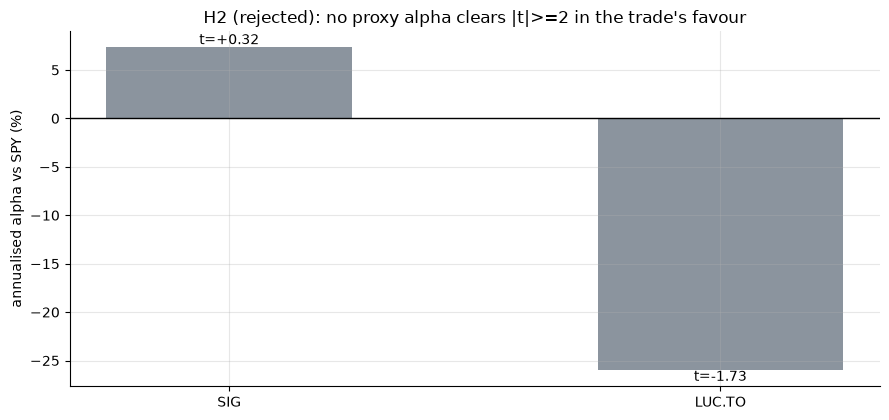

SIG     CAGR  +17.05%  Sharpe +0.61  maxDD  -77.8%  alpha +7.32%/yr  beta 1.91  NW t +0.32
LUC.TO  CAGR  -24.27%  Sharpe -0.32  maxDD  -88.8%  alpha -26.00%/yr  beta 0.82  NW t -1.73


In [3]:
if HAVE_PROXIES:
    spy_r = PROX['SPY'].pct_change().dropna()
    rows = {}
    for t in ['SIG','LUC.TO']:
        s = st.summarize(PROX[t]); nw = st.newey_west_alpha_t(PROX[t].pct_change().dropna(), spy_r, 6)
        rows[t] = dict(cagr=s['cagr']*100, sharpe=s['sharpe'], mdd=s['mdd']*100,
                       alpha=nw['alpha_ann']*100, beta=nw['beta'], t=nw['t_alpha'])
else:
    rows = {'SIG':dict(cagr=R['sig_cagr'],sharpe=R['sig_sharpe'],mdd=R['sig_mdd'],alpha=R['sig_alpha'],beta=R['sig_beta'],t=R['sig_t']),
            'LUC.TO':dict(cagr=R['luc_cagr'],sharpe=R['luc_sharpe'],mdd=R['luc_mdd'],alpha=R['luc_alpha'],beta=R['luc_beta'],t=R['luc_t'])}
labels=list(rows); alphas=[rows[t]['alpha'] for t in labels]; ts=[rows[t]['t'] for t in labels]
fig, ax = plt.subplots(figsize=(9.0, 4.3))
cols=[GREEN if abs(tt)>=2 else GREY for tt in ts]
ax.bar(labels, alphas, .5, color=cols)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('annualised alpha vs SPY (%)')
for i,t in enumerate(labels): ax.annotate(f"t={ts[i]:+.2f}",(i,alphas[i]),ha='center',va='bottom' if alphas[i]>=0 else 'top')
ax.set_title('H2 (rejected): no proxy alpha clears |t|>=2 in the trade\'s favour')
plt.tight_layout(); plt.show()
for t in labels: r=rows[t]; print(f"{t:7s} CAGR {r['cagr']:+7.2f}%  Sharpe {r['sharpe']:+.2f}  maxDD {r['mdd']:6.1f}%  alpha {r['alpha']:+.2f}%/yr  beta {r['beta']:.2f}  NW t {r['t']:+.2f}")

> 💡 In plain words: Signet is **β≈1.9** beta with an insignificant **+7%/yr** alpha (*t*=+0.32) — a jeweler that sells lab-grown too, it *rose* with the market. Lucara has a large *negative* alpha but only *t*=**-1.73** — sub-2, and it is **one** mine's idiosyncratic story (a single asset in Botswana), not a clean "diamond factor." **Neither clears \|t\| ≥ 2**: H₂ rejected. There is no listed instrument that hands you the diamond collapse as alpha.

### 4c · The short book — being right on direction, net of borrow (H₃, part 1)

"Short the diamond" = short the miner. Build a \$1 short book on LUC.TO, earn $-r$ each month, pay a **30%/yr** hard-to-borrow fee. The miner *cratered* — does the short pay?

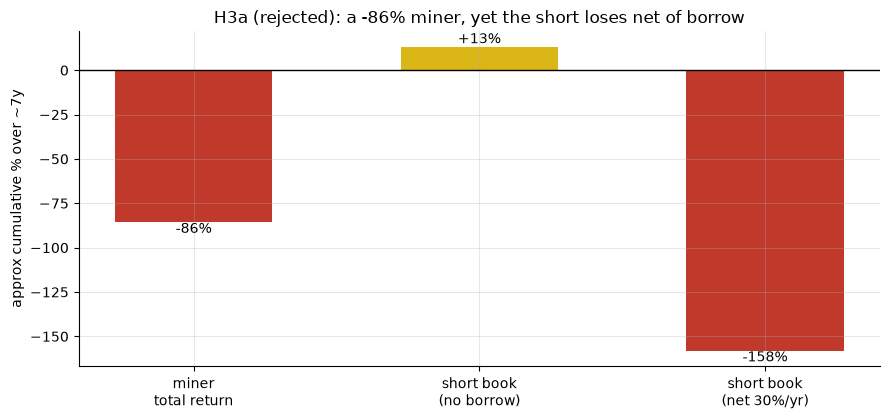

miner total -85.7%  |  short no-borrow CAGR +1.91%/yr (maxDD -76.2%)
short net of 30%/yr borrow: CAGR -22.59%/yr  vol 49.6%  maxDD -93.5%


In [4]:
if HAVE_PROXIES:
    luc_r = PROX['LUC.TO'].pct_change().dropna()
    sb0 = st.short_book_from_returns(luc_r, borrow_annual=0.0)
    sb  = st.short_book_from_returns(luc_r, borrow_annual=0.30)
    luc_total = PROX['LUC.TO'].iloc[-1]/PROX['LUC.TO'].iloc[0]-1
else:
    sb0={'cagr':R['short_nb_cagr']/100,'mdd':-0.762}; sb={'cagr':R['short_cagr']/100,'vol':R['short_vol']/100,'mdd':R['short_mdd']/100}
    luc_total=R['luc_total']/100
bars=['miner\ntotal return','short book\n(no borrow)','short book\n(net 30%/yr)']
vals=[luc_total*100, sb0['cagr']*100*7, sb['cagr']*100*7]
fig, ax = plt.subplots(figsize=(9.0,4.3))
ax.bar(bars, vals, .55, color=[RED, AMBER, RED])
ax.axhline(0, c='k', lw=1); ax.set_ylabel('approx cumulative % over ~7y')
for i,v in enumerate(vals): ax.annotate(f'{v:+.0f}%',(i,v),ha='center',va='bottom' if v>=0 else 'top')
ax.set_title('H3a (rejected): a -86% miner, yet the short loses net of borrow')
plt.tight_layout(); plt.show()
print(f"miner total {luc_total*100:+.1f}%  |  short no-borrow CAGR {sb0['cagr']*100:+.2f}%/yr (maxDD {sb0['mdd']*100:.1f}%)")
print(f"short net of 30%/yr borrow: CAGR {sb['cagr']*100:+.2f}%/yr  vol {sb['vol']*100:.1f}%  maxDD {sb['mdd']*100:.1f}%")

> 💡 In plain words: the miner fell **-86%**, yet the *gross* short book compounded at only **+1.9%/yr** — the +40%-plus up-months impose a vicious **volatility drag** (a short's payoff is concave in the underlying). Charge the **30%/yr** borrow and it flips to **-22.6%/yr** with a **-94%** drawdown. A perfectly correct directional call that **lost money**. H₃(a) rejected.

### 4d · The physical stone — net of the retail→resale haircut (H₃, part 2)

The "store of value" side never charges the round-trip: buy at **retail**, sell near **wholesale** (~55% over a 5y hold) plus carry. Charge it once on the index's gross CAGR (a *generous* read — the index level is already a wholesale-ish quote).

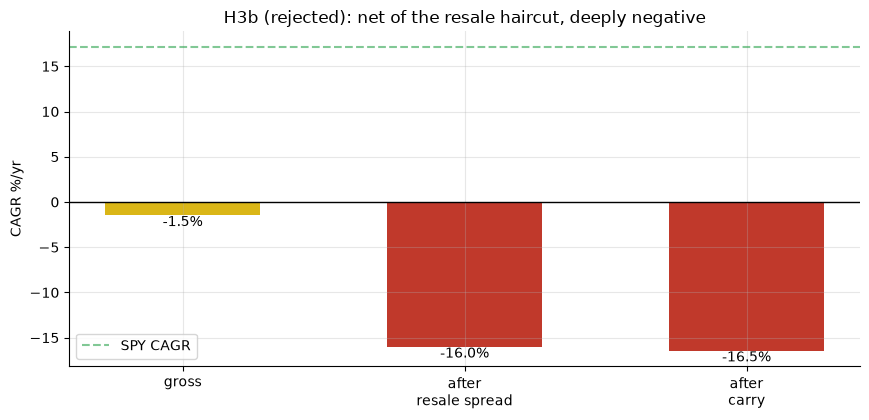

gross -1.49%  - resale -14.76%/yr  - carry -0.50%/yr  =  NET -16.45%/yr


In [5]:
h = st.net_of_resale_cagr(si['cagr'] if HAVE_PROXIES else R['idx_cagr']/100, round_trip_spread=0.55, hold_years=5.0, insure_per_year=0.005)
steps = ['gross','after\nresale spread','after\ncarry']
running = [h['gross_cagr']*100,
           ((1+h['gross_cagr'])*(1+h['spread_drag_annual'])-1)*100,
           h['net_cagr']*100]
fig, ax = plt.subplots(figsize=(8.8,4.3))
ax.bar(steps, running, .55, color=[AMBER, RED, RED])
ax.axhline(0, c='k', lw=1); ax.axhline(R['spy_cagr_ye'], ls='--', c=GREEN, alpha=.6, label='SPY CAGR')
for i,v in enumerate(running): ax.annotate(f'{v:+.1f}%',(i,v),ha='center',va='bottom' if v>=0 else 'top')
ax.set_ylabel('CAGR %/yr'); ax.set_title('H3b (rejected): net of the resale haircut, deeply negative'); ax.legend()
plt.tight_layout(); plt.show()
print(f"gross {h['gross_cagr']*100:+.2f}%  - resale {h['spread_drag_annual']*100:+.2f}%/yr  - carry {h['insure_per_year']*100:+.2f}%/yr  =  NET {h['net_cagr']*100:+.2f}%/yr")

> 💡 In plain words: the gross **-1.5%** — already a loser to SPY — becomes **-16.4%/yr** once you pay the retail→resale round-trip and carry. A diamond is a consumption good priced like one: the resale spread alone is larger than a decade of any plausible appreciation. H₃(b) rejected. **MIRAGE** is the only honest stamp.

### 4e · Positive control — the engine recovers a planted collapse

A deterministic peak-and-collapse path (planted modest boom +20% then bust −22% CAGR, σ=4.5%/mo, seed 716). The harness must recover the **down**-sign in the back half — proving the nulls above are real, not a pipeline that can't see a trend.

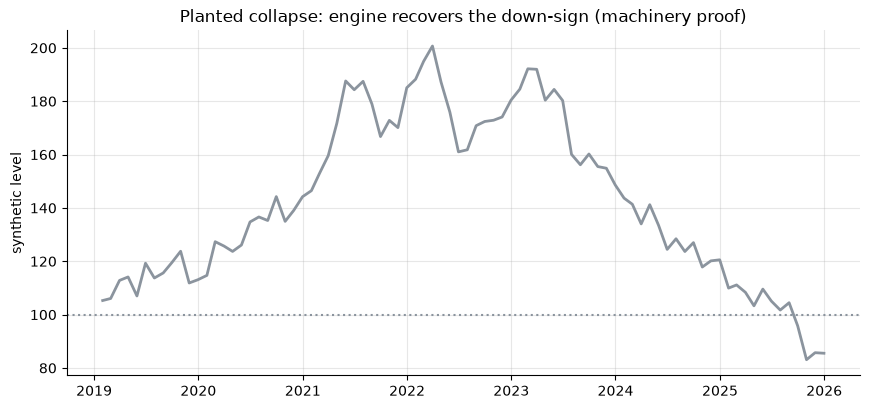

peak 201 -> end 86  back-half CAGR -17.01%  full Sharpe -0.08  maxDD -58.6%  sign_ok=1


In [6]:
syn = data.synthetic_collapse()
s = st.summarize(syn); cr = st.control_recovers(syn, planted_sign=-1)
fig, ax = plt.subplots(figsize=(8.8,4.2))
ax.plot(syn.index, syn.values, c=GREY, lw=2)
ax.axhline(100, ls=':', c=GREY)
ax.set_ylabel('synthetic level'); ax.set_title('Planted collapse: engine recovers the down-sign (machinery proof)')
plt.tight_layout(); plt.show()
print(f"peak {syn.max():.0f} -> end {syn.iloc[-1]:.0f}  back-half CAGR {cr['back_cagr']*100:+.2f}%  full Sharpe {s['sharpe']:+.2f}  maxDD {s['mdd']*100:.1f}%  sign_ok={cr['sign_ok']}")

> 💡 In plain words: the engine banks the planted **down**-trend (back-half CAGR ≈ −17%, sign correct). A *synthetic* control is a machinery proof, never market evidence — but it certifies that the `NONE`/`MIRAGE` stamps on the real tape are a true null, not a pipeline that couldn't detect a collapse. The collapse is *there*; the tradable edge is not.

## 5 · The verdict

- **Signal `NONE`** — no listed leg clears \|*t*\| ≥ 2 in the trade's favour (SIG *t*=+0.32, LUC.TO *t*=-1.73); the short book loses net of borrow. The index's −19%/yr shortfall (*t*=-2.30) rides on a **hardcoded proxy** and certifies the *diagnosis*, not a harvestable signal.
- **Tradability `MIRAGE`** — short LUC.TO net of 30%/yr borrow = **-22.6%/yr** (a -86% miner, and the short *still* lost); physical stone net of resale spread = **-16.4%/yr**. No diamond future, illiquid penny-stock borrow, nothing scales.
- **Diamonds collapsing? `CONFIRMED`** — natural-diamond prices really did round-trip **-32%** off the early-2022 peak as lab-grown scaled. The diagnosis is the best-supported part of the whole pitch — and the only part that's true.

## 6 · Could you trade it? — the capacity & cost reality

Terminal wealth of \$10,000 invested end-2018 across every diamond-collapse expression vs the S&P index fund. Capacity is the other wall: the pure-play short is a **\$0.20 penny-stock** — there is no borrow to source at size, and no listed diamond future to express the macro cleanly.

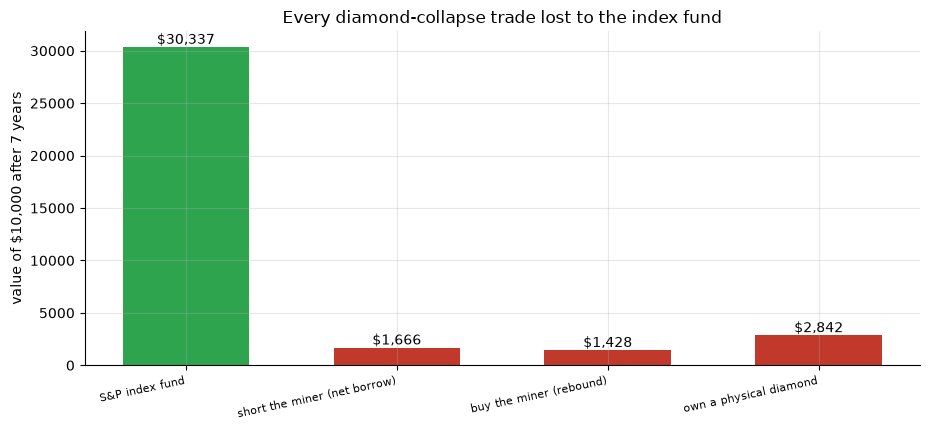

S&P index fund                   $    30,337  (+17.2%/yr)
short the miner (net borrow)     $     1,666  (-22.6%/yr)
buy the miner (rebound)          $     1,428  (-24.3%/yr)
own a physical diamond           $     2,842  (-16.4%/yr)


In [7]:
start=10_000.0; yrs_h=7
paths={'S&P index fund':R['spy_cagr']/100, 'short the miner (net borrow)':R['short_cagr']/100,
       'buy the miner (rebound)':R['luc_cagr']/100, 'own a physical diamond':R['haircut_net']/100}
fig, ax = plt.subplots(figsize=(9.4,4.4))
labels=list(paths); ends=[start*(1+g)**yrs_h for g in paths.values()]
cols=[GREEN, RED, RED, RED]
ax.bar(range(len(labels)), ends, .6, color=cols)
ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels, rotation=12, ha='right', fontsize=8)
for i,v in enumerate(ends): ax.annotate(f'${v:,.0f}',(i,v),ha='center',va='bottom')
ax.set_ylabel('value of $10,000 after 7 years'); ax.set_title('Every diamond-collapse trade lost to the index fund')
plt.tight_layout(); plt.show()
for l,g in paths.items(): print(f"{l:32s} ${start*(1+g)**yrs_h:>10,.0f}  ({g*100:+.1f}%/yr)")

> 💡 In plain words: the correct macro call — *diamonds are collapsing* — could not be monetised on **any** leg. The short loses to borrow + vol drag, the contrarian long is a value trap, the physical stone is a consumption good. And capacity is fatal: a \$0.20 penny-stock has no shortable float at size and there is no diamond future. There is no venue, sizing, or instrument that turns this diagnosis into an edge.

## 7 · Going further

- **Swap in the live index.** Replace the hardcoded series with Rapaport RAPI / IDEX / Zimnisky levels and re-run; the diagnosis sharpens, the tradability verdict won't move.
- **A diversified short.** Anglo American (De Beers' parent) or a miner basket lowers the borrow/vol problem but dilutes the diamond signal into mining beta — test whether *any* weighting recovers a positive net-of-borrow CAGR (we doubt it).
- **The 'right diagnosis, no trade' family.** Correctly-called, obvious, multi-year declines that still can't be shorted for profit — a recurring desk theme ([docs/references.md](../docs/references.md)).

*The reproducible core is offline and deterministic; the price index is a **cited, approximate proxy** and the equity tickers are **labelled proxies** for the trade. Methods: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*